# Bài toán: Phân vùng trọng điểm đón khách trong thành phố New York

## Thành viên:
* Huỳnh Anh Nhựt
* Huỳnh Anh Tuấn
* Nguyễn Tiến Minh

NYC Taxi dataset chứa hàng triệu điểm pickup trải rộng trên toàn thành phố New York.

Tuy nhiên, hoạt động taxi không phân bố đồng đều mà thường tập trung tại một số khu vực có nhu cầu cao.

Vì vậy, mục tiêu của bài toán này là:
* Khám phá cấu trúc không gian của dữ liệu taxi NYC
* Phát hiện có phân vùng điểm đón trọng điểm của taxi NYC
* Hỗ trợ các doanh nghiệp tối ưu hóa vận hành và phân bổ tài xế hợp lý cho từng khu vực

## Import thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load dữ liệu

In [2]:
taxi_df = pd.read_csv('../data/processed/yellow_tripdata_2016-03_processed.csv')

taxi_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,...,total_amount,trip_duration,speed,pickup_hour,pickup_dayofweek,pickup_month,time_of_day,is_peak_hour,is_credit_card,total_income
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,...,12.35,475.0,18.947368,0,1,3,night,0,1,11.05
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,...,15.35,666.0,15.675676,0,1,3,night,0,1,14.05
2,1,2016-03-01 00:00:01,2016-03-01 00:16:04,1,6.20,-73.788773,40.647758,1,N,-73.829208,...,21.80,963.0,23.177570,0,1,3,night,0,0,20.50
3,1,2016-03-01 00:00:01,2016-03-01 00:05:00,1,0.70,-73.958221,40.764641,1,N,-73.967896,...,8.80,299.0,8.428094,0,1,3,night,0,1,7.50
4,2,2016-03-01 00:00:01,2016-03-01 00:24:06,3,7.18,-73.985779,40.741192,1,N,-73.946350,...,28.00,1445.0,17.887889,0,1,3,night,0,1,26.70


## Vấn đề dữ liệu tọa độ

### Nhiều mẫu tọa độ lỗi và bất thường

In [3]:
zero_coords = (
    (taxi_df['pickup_longitude'] == 0) | (taxi_df['pickup_latitude'] == 0)  
)
zero = zero_coords

c:\Users\MSI VN\.conda\envs\seminar_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


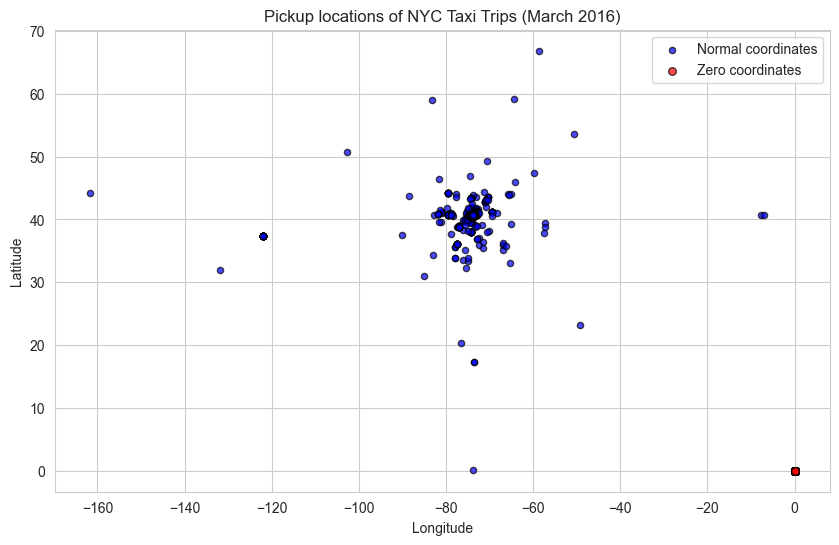

In [4]:
plt.figure(figsize=(10, 6))

normal = ~zero_coords 

# normal
plt.scatter(
    taxi_df.loc[normal , 'pickup_longitude'], 
    taxi_df.loc[normal , 'pickup_latitude'], 
    alpha=0.7,
    color='blue',
    s=20,
    label='Normal coordinates',
    edgecolors='black',
    zorder=1
)

# zero
plt.scatter(
    taxi_df.loc[zero_coords, 'pickup_longitude'],
    taxi_df.loc[zero_coords, 'pickup_latitude'],
    alpha=0.7,
    color='red',
    s=30,
    edgecolors='black',
    label='Zero coordinates',
    zorder=2
)

plt.title('Pickup locations of NYC Taxi Trips (March 2016)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

### Nhận xét:
* Ta nhận thấy được có những điểm đỏ là những điểm có tọa độ = 0 là các điểm tọa độ bất thường vì chúng ko hề nằm trong phạm vi thành phố New York hay Mỹ mà nằm ở ngoài Đại Tây Dương
* Có những điểm khác nằm khá xa NYC được xem là bất hợp lý và hầu hết được xuất hiện do lỗi dữ liệu, các mẫu lỗi cần được xử lý để làm sạch dữ liệu trước khi đưa vào các mô hình dựa đoán

### Điểm đón trong NYC

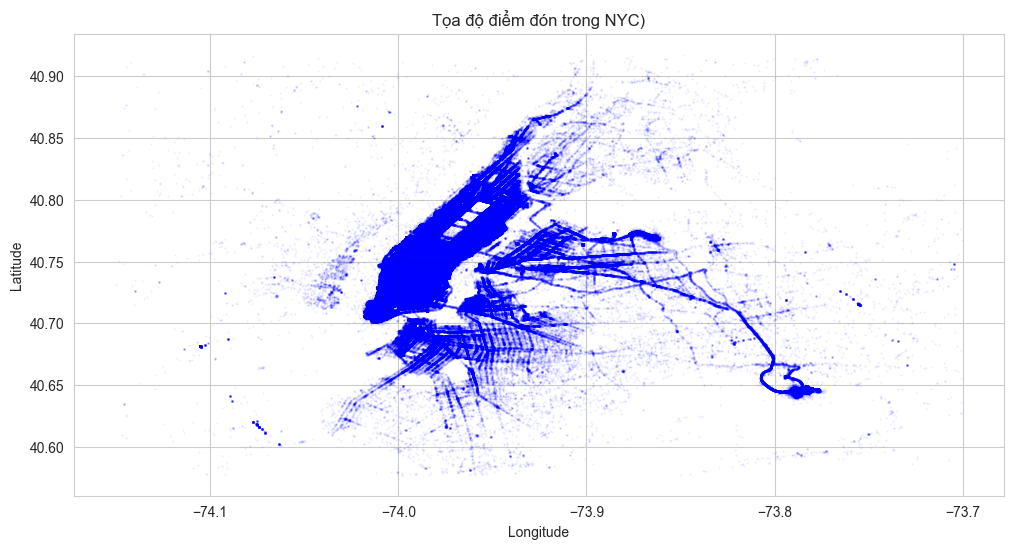

In [ ]:
nyc_min_lat, nyc_max_lat = 40.5774, 40.9176
nyc_min_lon, nyc_max_lon = -74.15, -73.7004

plt.figure(figsize=(12, 6))
plt.scatter(
    taxi_df.loc[(taxi_df['pickup_longitude'] >= nyc_min_lon) & (taxi_df['pickup_longitude'] <= nyc_max_lon) , 'pickup_longitude'], 
    taxi_df.loc[(taxi_df['pickup_latitude'] >= nyc_min_lat) & (taxi_df['pickup_latitude'] <= nyc_max_lat) , 'pickup_latitude'], 
    alpha=0.05,
    color='blue',
    s=0.5,
    label='Pickup',
)
plt.title('Tọa độ điểm đón trong NYC)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Nhận xét:
* Biểu đồ trên thể hiện phân phối tọa độ điểm đón trong NYC. Tuy nhiên, nếu chỉ quan sát trực tiếp dữ liệu tọa độ, sẽ rất khó nhận biết các khu vực có mật độ điểm đón cao cũng như cấu trúc phân bố không gian của hoạt động taxi.

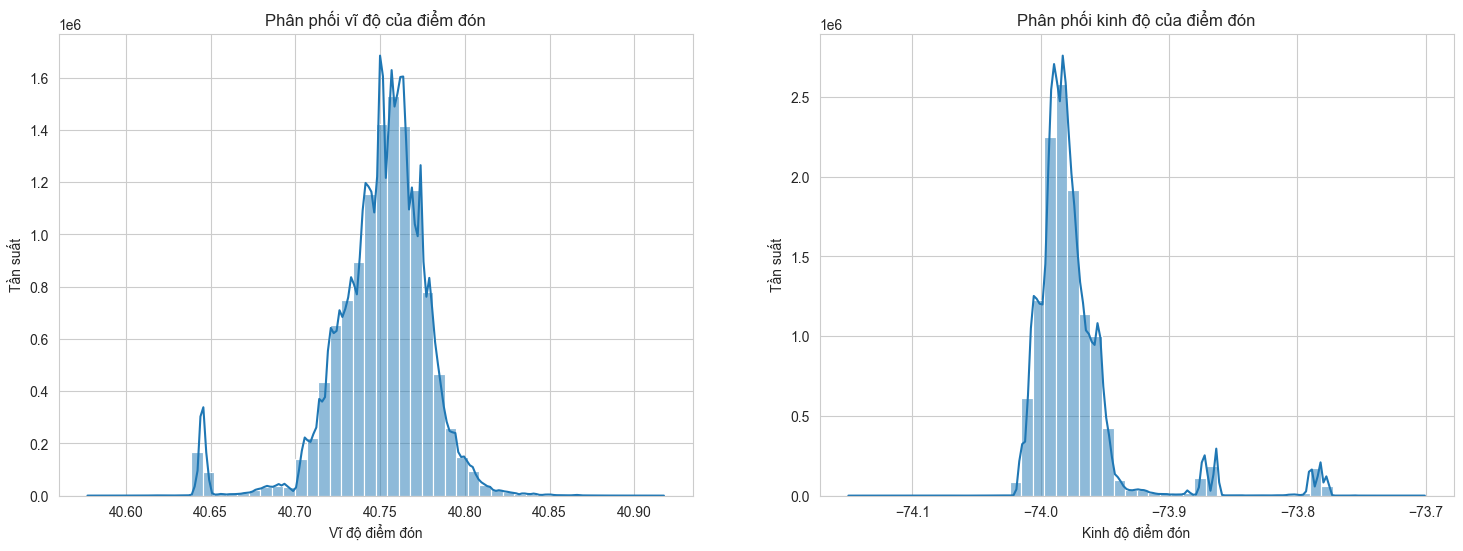

In [10]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.histplot(x=taxi_df.loc[(taxi_df['pickup_latitude'] >= nyc_min_lat) & (taxi_df['pickup_latitude'] <= nyc_max_lat) , 'pickup_latitude'], bins=50, kde=True)
plt.title('Phân phối vĩ độ của điểm đón')
plt.ylabel('Tần suất')
plt.xlabel('Vĩ độ điểm đón')

plt.subplot(1, 2, 2)
sns.histplot(x=taxi_df.loc[ (taxi_df['pickup_longitude'] >= nyc_min_lon) & (taxi_df['pickup_longitude'] <= nyc_max_lon), 'pickup_longitude'], bins=50, kde=True)
plt.title('Phân phối kinh độ của điểm đón')
plt.ylabel('Tần suất')
plt.xlabel('Kinh độ điểm đón')

plt.show()

### Nhận xét:
* Cả hai biểu đồ cho thấy tọa độ pickup phân bổ không đồng đều mà tập trung tại nhiều khu vực khác nhau trong thành phố NYC, có nhiều nơi có tần suất đón khá cao và những nơi có tần suất đón thấp.
* Đặc biệt, sự xuất hiện của nhiều peak density cho thấy khả năng tồn tại các hotspot taxi tự nhiên trong thành phố.
* Vì vậy, nhóm tiến hành áp dụng spatial clustering nhằm tìm ra các hotspot trọng điểm trong thành phố.

## Thực hiện phân cụm Hotspot

### Phương pháp bài toán

- Nhóm quyết định sử dụng DBScan để thực hiện bài toán phân cụm các vùng đón khách trọng điểm trong NYC, vì DBScan có thể phân ra các cụm tương ứng với hình dạng đặc thù của khu vực đó
- Vì dữ liệu quá lớn với hàng triệu mẫu nên nhóm quyết định chỉ lấy dùng phương pháp subsampling để lấy 1 phần cũ dữ liệu đi phân cụm. Sau khi xác định được các cụm trọng điểm, nhóm tiếp tục sử dụng thuật toán K-Nearest Neighbors (KNN) để gán nhãn cụm cho các điểm dữ liệu còn lại. Phương pháp này giúp giải quyết bài toán phân cụm với DBScan trên tập dữ liệu lớn với độ chính xác phân cụm và chi phí tính toán được tối ưu hóa.

In [3]:
from sklearn.neighbors import NearestNeighbors
# 1) Sample

np.random.seed(42)

nyc_min_lat, nyc_max_lat = 40.5774, 40.9176
nyc_min_lon, nyc_max_lon = -74.15, -73.7004

taxi_df = taxi_df[(taxi_df['pickup_latitude'] >= nyc_min_lat) & (taxi_df['pickup_latitude'] <= nyc_max_lat) &
            (taxi_df['pickup_longitude'] >= nyc_min_lon) & (taxi_df['pickup_longitude'] <= nyc_max_lon) &
            (taxi_df['dropoff_latitude'] >= nyc_min_lat) & (taxi_df['dropoff_latitude'] <= nyc_max_lat) &
            (taxi_df['dropoff_longitude'] >= nyc_min_lon) & (taxi_df['dropoff_longitude'] <= nyc_max_lon)]


sample_size = 100000
idx = np.random.choice(len(taxi_df), sample_size, replace=False)
coords = taxi_df[['pickup_latitude','pickup_longitude']].values
coords_rad = np.radians(coords)

sample = coords_rad[idx]

# 2) DBSCAN trên sample
EARTH_RADIUS = 6371
eps = 0.3 / EARTH_RADIUS  # ~300m

db = DBSCAN(eps=eps, min_samples=100, metric='haversine', algorithm='ball_tree')
labels_sample = db.fit_predict(sample)

# 3) Lấy core points
core_samples = sample[db.core_sample_indices_]
core_labels = labels_sample[db.core_sample_indices_]

# 4) Gán lại toàn bộ data bằng nearest core
nbrs = NearestNeighbors(n_neighbors=1, metric='haversine').fit(core_samples)
dist, ind = nbrs.kneighbors(coords_rad)

# nếu xa quá thì coi là noise
threshold = eps
full_labels = np.where(dist.flatten() < threshold, core_labels[ind.flatten()], -1)

taxi_df['location_cluster'] = full_labels



In [7]:
n_clusters = np.sort(taxi_df['location_cluster'].unique())
n_noise = taxi_df['location_cluster'].value_counts()

print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {n_noise}")

Number of clusters: [-1  0  1  2  3  4]
Noise points: location_cluster
 0    10668458
-1      454574
 1      238536
 2       27468
 4       12775
 3       10107
Name: count, dtype: int64


### Kết quả phân cụm

C:\Users\MSI VN\AppData\Local\Temp\ipykernel_15896\2833244008.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
C:\Users\MSI VN\AppData\Local\Temp\ipykernel_15896\2833244008.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
c:\Users\MSI VN\.conda\envs\seminar_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


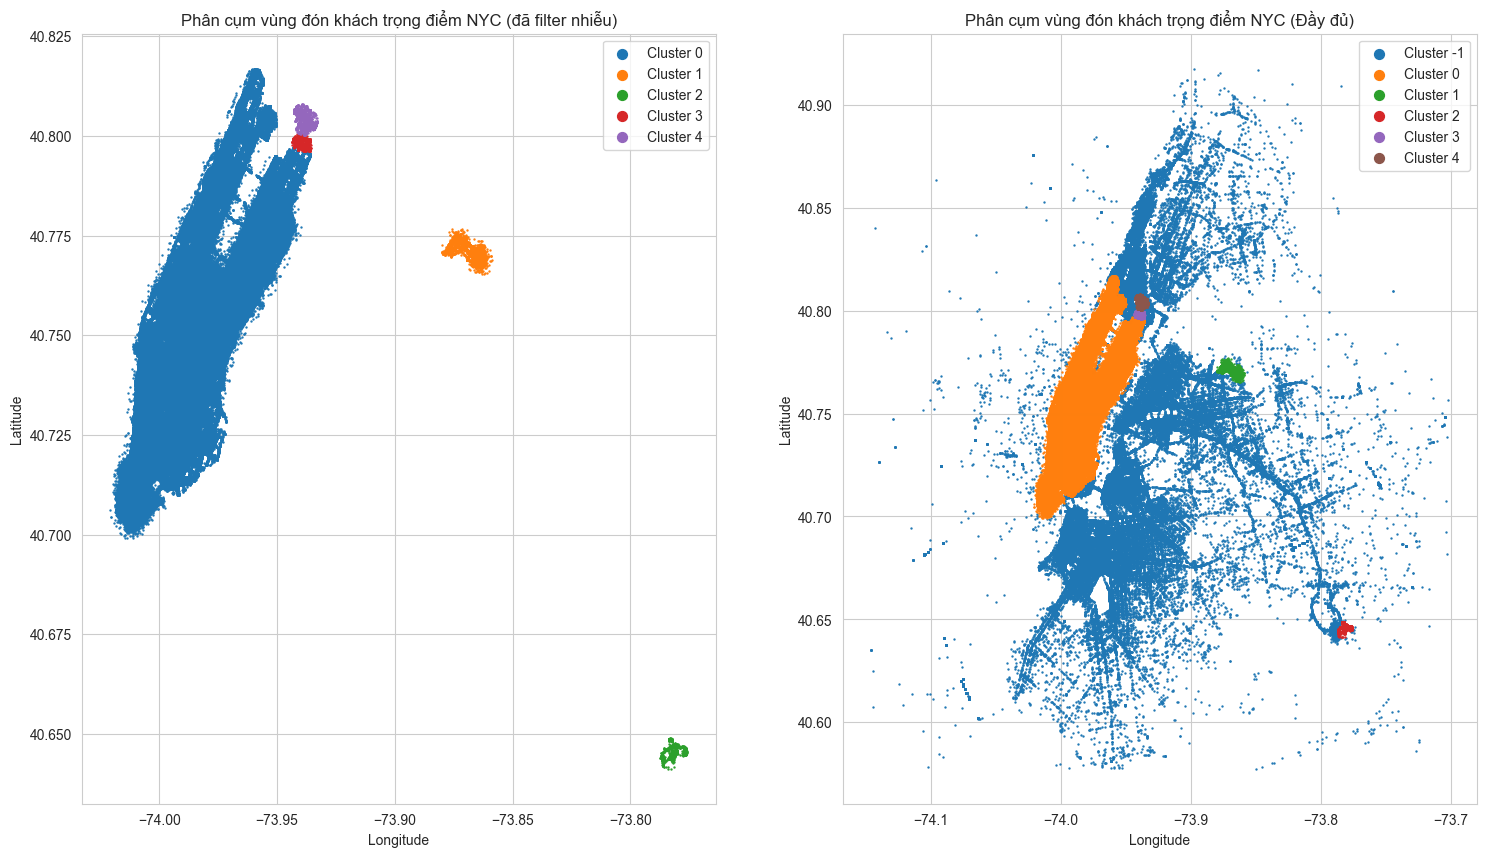

In [6]:
# lấy unique cluster
unique_clusters = np.sort(taxi_df['location_cluster'].unique())

plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
for cluster_id in unique_clusters:

    if cluster_id != -1:
        cluster_data = taxi_df[
            taxi_df['location_cluster'] == cluster_id
        ]

        plt.scatter(
            cluster_data['pickup_longitude'],
            cluster_data['pickup_latitude'],
            cmap='tab10',
            s=0.5,
            label=f'Cluster {cluster_id}'
        )

plt.title("Phân cụm vùng đón khách trọng điểm NYC (đã filter nhiễu)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(markerscale=10)

plt.subplot(1, 2, 2)
for cluster_id in unique_clusters:
        
        cluster_data = taxi_df[
            taxi_df['location_cluster'] == cluster_id
        ]

        plt.scatter(
            cluster_data['pickup_longitude'],
            cluster_data['pickup_latitude'],
            cmap='tab10',
            s=0.5,
            label=f'Cluster {cluster_id}'
        )

plt.title("Phân cụm vùng đón khách trọng điểm NYC (Đầy đủ)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(markerscale=10)
plt.show()

### Hình ảnh bản đồ NYC (Google Map)

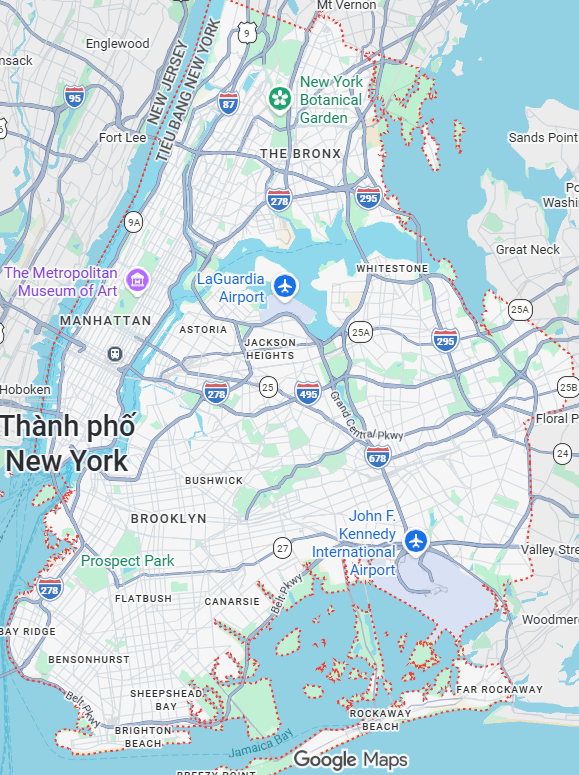

In [8]:
from IPython.display import Image, display

display(Image(filename='./img/NYC_map.png'))

### Phân tích biểu đồ
* Ở biểu đồ trái, ta thấy các chuyến taxi phần lớn tập trung mạnh tại khu vực Manhattan. Đây là cụm lớn nhất và các mật độ taxi dày đặc nhất trong thành phố New York. Điều này phản ánh khu vực Manhattan là khu vực đông đúc nhất bao gồm các trung tâm tài chính, thương mại, du lịch và giải trí của thành phố New York.

* Ngoài ra, DBSCAN còn phát hiện ra 2 cụm nằm tách biệt ra khỏi trung tâm thành phố. Các cụm này nằm tương ứng với các địa điểm sân bay và giao thông trọng điểm của NYC. Các cụm tách biệt này có vị trí địa lý tương ứng với 2 sân bay lớn của thành phố New York, cho thấy như cầu đón taxi ở các sân bay là khá cao.

* Đáng chú ý, hai cluster nhỏ (Cluster 3 và Cluster 4) nằm khá gần nhau nhưng vẫn được DBSCAN tách thành hai cụm riêng biệt. Điều này cho thấy mặc dù cùng nằm trong khu vực Manhattan, hai vùng này vẫn có sự khác biệt nhất định về mật độ phân bố hoặc cấu trúc không gian của các điểm đón khách. Đây có thể là các khu vực trung tâm kết nối với nhiều tuyến đường huyết mạch và có lưu lượng taxi đặc biệt cao.

* Biểu đồ phải, ta thấy được có 1 số lượng lớn dữ liệu bị DBSCAN gán vào nhóm nhiễu (Cluster -1). Các điểm này nằm rải rác khác nơi, nhưng mật độ không đủ lớn để có thể được phân cụ. Điều này phản ánh hoạt động taxi tại NYC không chỉ tập trung tại các hotspot lớn mà còn trải rộng trên toàn thành phố để phục vụ nhu cầu di chuyển đa dạng của người dân.

* Với số lượng nhiễu khá lớn, nhưng DBSCAN vẫn có thể phân vùng rõ được các hotspot tách biệt rất rõ ràng. Cho thấy DBSCAN có khả năng lọc bỏ hiệu quả các điểm phân tán và chỉ giữ lại các vùng có mật độ hoạt động thực sự cao. Đây là ưu điểm quan trọng trong bài toán phân tích không gian, đặc biệt với dữ liệu taxi vốn chứa nhiều nhiễu và phân bố không đồng đều.


### Dùng cluster làm feature cho các bài toán phía sau

In [11]:
taxi_df.to_csv('../data/processed/yellow_tripdata_2016-03_processed.csv')